In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    src: float
    bph: float
    boundary_percent: float


In [ ]:
def cal_src(state: BatsmanState)->BatsmanState:
    src = (state['runs']/state['balls'])*100
    return {'src':src}

def cal_bph(state: BatsmanState)->BatsmanState:
    bph = state['balls']/(state['fours'] + state['sixes'])
    return {'bph':bph}

def cal_boundary_percent(state: BatsmanState)->BatsmanState:
    boundary_percent = (state['fours']*4) + (state['sixes']*6)/state['runs'] *100
    return {'boundary_percent':boundary_percent}

def summary(state: BatsmanState)->BatsmanState:
    summary1 = f"Strike Rate - {state['src']} \n   Balls per boundary - {state['bph']} \n boundary percent - {state['boundary_percent']}"
    return {'summary':summary1}

In [4]:
graph = StateGraph(BatsmanState)

graph.add_node('cal_src', cal_src)
graph.add_node('cal_bph', cal_bph)
graph.add_node('cal_boundary_percent', cal_boundary_percent)
graph.add_node('summary', summary)

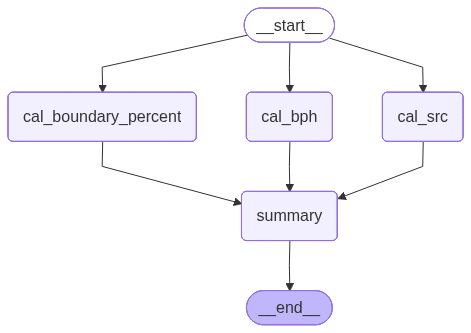

In [5]:
graph.add_edge(START, 'cal_src')
graph.add_edge(START,'cal_bph')
graph.add_edge(START,'cal_boundary_percent')

graph.add_edge('cal_src','summary')
graph.add_edge('cal_bph','summary')
graph.add_edge('cal_boundary_percent','summary')

graph.add_edge('summary',END)
wfs = graph.compile()
wfs

In [6]:
init = {'runs': 200,
    'balls': 150,
    'fours': 15,
    'sixes': 6}
final = wfs.invoke(init)

In [7]:
final['src']

133.33333333333331

In [8]:
final['bph']

7.142857142857143

In [9]:
final['boundary_percent']

78.0